In [2]:
import numpy as np
from pandas import read_csv
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [3]:
df = read_csv("../../datasets/heart-disease.csv")
df.head(5)

,age,sex,chest pain type,resting blood presure,serum cholestoral,fasting blood sugar > 120 mg/dl,resting electrocardiographic results,maximum heart rate achieved,exercise induced angina,ST depression induced by exercise relative to rest,the slope of the peak exercise ST segment,number of major vessels (0-3) colored by flourosopy,thal,diagnosis of heart disease
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


In [4]:
df.dtypes

age                                                      int64
sex                                                      int64
chest pain type                                          int64
resting blood presure                                    int64
serum cholestoral                                        int64
fasting blood sugar > 120 mg/dl                          int64
resting electrocardiographic results                     int64
maximum heart rate achieved                              int64
exercise induced angina                                  int64
ST depression induced by exercise relative to rest     float64
the slope of the peak exercise ST segment                int64
number of major vessels (0-3) colored by flourosopy     object
thal                                                    object
diagnosis of heart disease                               int64
dtype: object

In [5]:
index_to_delete = []

for i in range(df.shape[0]):
    for j in range(14):
        if str(df.iloc[i].iloc[j]) == '?':
            print("found non numeric value in %ith column and %ith row"%(i, j))
            index_to_delete.append(i)
            
ndf = df.drop(index=index_to_delete).reset_index()

ndf.head(5)

found non numeric value in 87th column and 12th row
found non numeric value in 166th column and 11th row
found non numeric value in 192th column and 11th row
found non numeric value in 266th column and 12th row
found non numeric value in 287th column and 11th row
found non numeric value in 302th column and 11th row


,index,age,sex,chest pain type,resting blood presure,serum cholestoral,fasting blood sugar > 120 mg/dl,resting electrocardiographic results,maximum heart rate achieved,exercise induced angina,ST depression induced by exercise relative to rest,the slope of the peak exercise ST segment,number of major vessels (0-3) colored by flourosopy,thal,diagnosis of heart disease
0,0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,1
2,2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


In [6]:
ndf.columns

Index(['index', 'age', 'sex', 'chest pain type', 'resting blood presure',
       'serum cholestoral', 'fasting blood sugar > 120 mg/dl',
       'resting electrocardiographic results', 'maximum heart rate achieved',
       'exercise induced angina',
       'ST depression induced by exercise relative to rest',
       'the slope of the peak exercise ST segment',
       'number of major vessels (0-3) colored by flourosopy', 'thal',
       'diagnosis of heart disease'],
      dtype='object')

In [7]:
x = ndf[['age', 'sex', 'chest pain type', 'resting blood presure',
       'serum cholestoral', 'fasting blood sugar > 120 mg/dl',
       'resting electrocardiographic results', 'maximum heart rate achieved',
       'exercise induced angina',
       'ST depression induced by exercise relative to rest',
       'the slope of the peak exercise ST segment',
       'number of major vessels (0-3) colored by flourosopy', 'thal']].values
x[0:5]

array([[63, 1, 1, 145, 233, 1, 2, 150, 0, 2.3, 3, '0', '6'],
       [67, 1, 4, 160, 286, 0, 2, 108, 1, 1.5, 2, '3', '3'],
       [67, 1, 4, 120, 229, 0, 2, 129, 1, 2.6, 2, '2', '7'],
       [37, 1, 3, 130, 250, 0, 0, 187, 0, 3.5, 3, '0', '3'],
       [41, 0, 2, 130, 204, 0, 2, 172, 0, 1.4, 1, '0', '3']], dtype=object)

In [8]:
y = ndf['diagnosis of heart disease'].values
y[0:5]

array([0, 1, 1, 0, 0], dtype=int64)

In [9]:
scaler = preprocessing.StandardScaler().fit(x)
x = scaler.fit_transform(x)
x[0:5]

array([[ 0.93618065,  0.69109474, -2.24062879,  0.75038004, -0.27644339,
         2.43042728,  1.01019851,  0.01749443, -0.69641941,  1.06896529,
         2.26414539, -0.72197605,  0.65587737],
       [ 1.3789285 ,  0.69109474,  0.87388018,  1.59626645,  0.74455507,
        -0.41145029,  1.01019851, -1.81633388,  1.43591632,  0.38177332,
         0.6437811 ,  2.47842525, -0.89422007],
       [ 1.3789285 ,  0.69109474,  0.87388018, -0.65943064, -0.35349988,
        -0.41145029,  1.01019851, -0.89941972,  1.43591632,  1.32666228,
         0.6437811 ,  1.41162482,  1.17257652],
       [-1.94168041,  0.69109474, -0.16428947, -0.09550637,  0.05104668,
        -0.41145029, -1.00341866,  1.63300986, -0.69641941,  2.09975324,
         2.26414539, -0.72197605, -0.89422007],
       [-1.49893255, -1.44697961, -1.20245913, -0.09550637, -0.83510292,
        -0.41145029,  1.01019851,  0.97807117, -0.69641941,  0.29587432,
        -0.97658319, -0.72197605, -0.89422007]])

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=5)
print("training data: ", x_train.shape, y_train.shape)
print("testing data: ", x_test.shape, y_test.shape)

training data:  (237, 13) (237,)
testing data:  (60, 13) (60,)


In [11]:
Ks = 16
mean_acc = np.zeros((Ks-1))
fscores = np.zeros((Ks-1))

for n in range(1, Ks):
    neigh = KNeighborsClassifier(n_neighbors=n).fit(x_train, y_train)
    yhat = neigh.predict(x_test)

    print(f"k={n} acc={accuracy_score(y_test, yhat)} f1_s={f1_score(y_test, yhat, average='weighted')}")


k=1 acc=0.8166666666666667 f1_s=0.8171355498721228
k=2 acc=0.8166666666666667 f1_s=0.8100775193798451
k=3 acc=0.8833333333333333 f1_s=0.8836317135549872
k=4 acc=0.85 f1_s=0.8466666666666666
k=5 acc=0.8 f1_s=0.7986111111111112
k=6 acc=0.7833333333333333 f1_s=0.7808704945108327
k=7 acc=0.7666666666666667 f1_s=0.7650462962962964
k=8 acc=0.7833333333333333 f1_s=0.7808704945108327
k=9 acc=0.7666666666666667 f1_s=0.7650462962962964
k=10 acc=0.8 f1_s=0.7967097532314924
k=11 acc=0.8166666666666667 f1_s=0.8145827261245506
k=12 acc=0.85 f1_s=0.8466666666666666
k=13 acc=0.8666666666666667 f1_s=0.8657407407407407
k=14 acc=0.8333333333333334 f1_s=0.8305914610262436
k=15 acc=0.85 f1_s=0.8482949577382686


In [12]:
# The best K would be 3.
neigh = KNeighborsClassifier(n_neighbors=3).fit(x_train, y_train)
neigh

KNeighborsClassifier(n_neighbors=3)

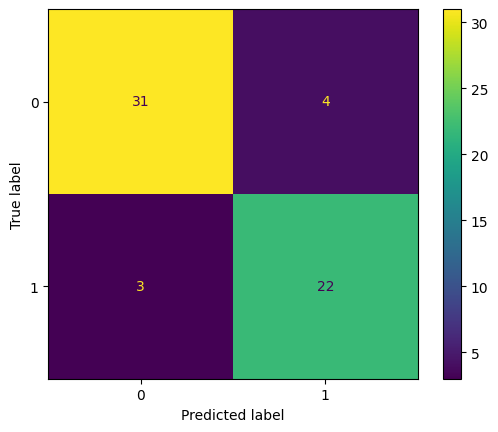

In [13]:
cm = confusion_matrix(y_test, neigh.predict(x_test))
disp = ConfusionMatrixDisplay(cm)
disp.plot()